## Лабораторная работа 4. Слияние изображений

#### $\S$ 1. Регистрация изображений

Регистрация изображения - это процесс выравнивания двух или более изображений одной и той же сцены. Этот процесс включает в себя назначение одного изображения в качестве эталонного изображения, также называемого фиксированным изображением, и применение проективных преобразований к другим изображениям так, чтобы они были выровнены с эталоном.

### Прудникова Анастасия 214
#### Вариант 23

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pywt
import cv2
%matplotlib inline

(np.float64(-0.5), np.float64(183.5), np.float64(185.5), np.float64(-0.5))

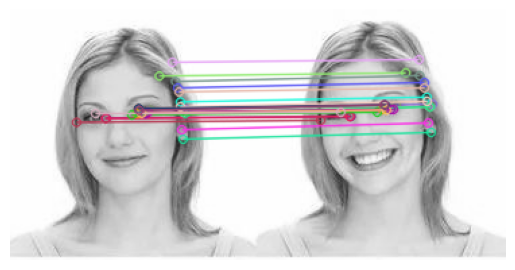

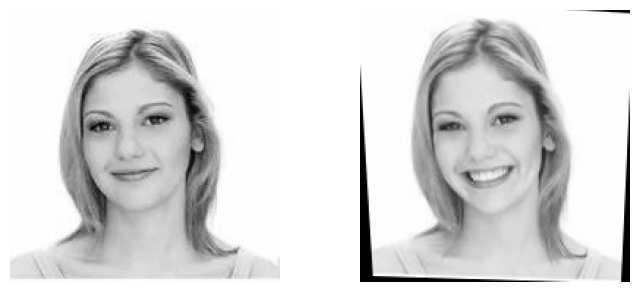

In [6]:
'''....... Регистрация изображений ...........'''

img = np.array(Image.open('Регистрация.jpg').convert('L'))
M = np.int64(img.shape[1] / 2)
img_1 = img[:, :M]
img_2 = img[:, M:(2*M)]
orb = cv2.ORB_create()
# Находим локальные особенности и дескриптор с помощью sift
kp1, des1 = orb.detectAndCompute(img_1, None)
kp2, des2 = orb.detectAndCompute(img_2, None)
# Для споставления дескрипторов
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Сопоставляем дескрипторы
matches = bf.match(des1, des2)
# Первые - самые точные соответствия
matches = sorted(matches, key = lambda x:x.distance)
N = 25
img3 = cv2.drawMatches(img_1, kp1, img_2, kp2, matches[:N], None, flags = 2)
plt.figure()
plt.imshow(img3)
plt.axis('off')

''' Формируем два массива соответствующих точек '''
matchedPoints1 = np.zeros((3, N)) + 1
matchedPoints2 = np.zeros((3, N)) + 1
Points1 = np.zeros((2, N))
Points2 = np.zeros((2, N))
for i in range(N):
    ikp1 = matches[i].queryIdx
    ikp2 = matches[i].trainIdx
    matchedPoints1[0,i] = kp1[ikp1].pt[0]
    matchedPoints1[1,i] = kp1[ikp1].pt[1]
    matchedPoints2[0,i] = kp2[ikp2].pt[0]
    matchedPoints2[1,i] = kp2[ikp2].pt[1]
Points1[:,:] = matchedPoints1[:2,:]
Points2[:,:] = matchedPoints2[:2,:]

''' Построение гомографии '''
h, status = cv2.findHomography(Points2.T, Points1.T)
img_2_out = cv2.warpPerspective(img_2, h, (img_1.shape[1], img_1.shape[0]))
fig = plt.figure(figsize = (8, 5))
fig.subplots_adjust(hspace = 0.3, wspace = 0.3)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
ax1.imshow(img_1, cmap = 'gray')
ax2.imshow(img_2_out, cmap = 'gray')
ax1.axis('off')
ax2.axis('off')

#### $\S$ 2. Слияние изображений

Целью слияния изображений -- является объединение информации из нескольких изображений одной и той же сцены. Результатом слияния изображений является новое изображение, которое больше подходит для восприятия человеком или машиной или для дальнейших задач обработки изображений.

Ключевым этапом в слиянии изображений на основе вейвлетов является объединение коэффициентов, а именно процесс объединения коэффициентов соответствующим образом, чтобы получить наилучшее качество объединенного изображения.

**Алгоритм слияния изображений одного размера.**

1. Регистрация и масштабирование изображений (должен быть одинаковый размер)

2. Применяем к обоим изображениям $X, Y$ дискретное вейвлет-преобразование $W$, получаем набор матриц коэффициентов $D_X$, $D_Y$. Пусть $p = (m; n; k; l)$ обозначает индекс, соответствующий определённому вейвлет-коэффициенту (уровень разложения $k$, матрица $l$ в уровне $k$, коэффициент с индексами $m,n$ в матрице).

3. Селекция. Формируем новый набор матриц коэффициентов $D_Z(p) = D_i (p)$, где $i = X$ или $Y$ в зависимости от того, какое исходное изображение удовлетворяет условию

$$
i = \arg\max\limits_{X, Y}(|D_X(p)|, |D_Y(p)|).
$$

4. К набору коэффициентов $D_Z$ применяем обратное вейвлет-преобразование $W^{-1}$, получаем новое изображение $Z$, представляющее собой слияние изображений $X$ и $Y$.

In [29]:
img = np.array(Image.open('LW_4_Fig_3.jpeg').convert('L'))
M = np.int64(img.shape[1] / 2)

(np.float64(-0.5), np.float64(649.5), np.float64(365.5), np.float64(-0.5))

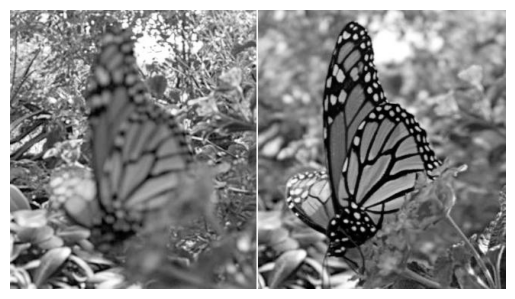

In [30]:
plt.imshow(img, cmap = 'gray')
plt.axis('off')

In [24]:
img_1 = img[:, :M]
img_2 = img[:, M:(2*M)]
print(img_1.shape)
print(img_2.shape)

(366, 325)
(366, 325)


(np.float64(-0.5), np.float64(324.5), np.float64(365.5), np.float64(-0.5))

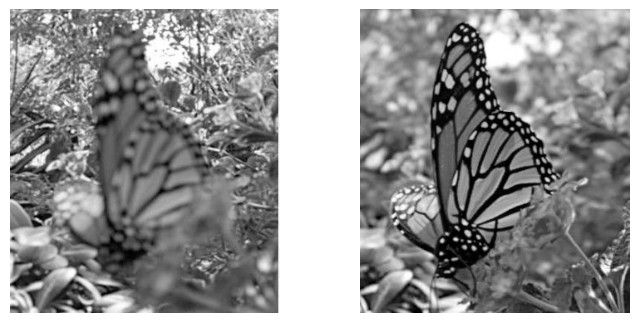

In [28]:
fig = plt.figure(figsize = (8, 5))
fig.subplots_adjust(hspace = 0.3, wspace = 0.3)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
ax1.imshow(img_1, cmap = 'gray')
ax2.imshow(img_2, cmap = 'gray')
ax1.axis('off')
ax2.axis('off')

Ваш код:

1. Регистрация изображений:
   1.1 Нахождение точечных соответствий
   1.2 Построение гомографии

2. Слияние изображений. Реализация алгоритма.

array([[156, 158, 172, ..., 137, 249, 249],
       [156, 158, 177, ..., 149, 250, 249],
       [143, 154, 171, ..., 184, 250, 250],
       ...,
       [138, 142, 144, ...,  97, 249, 251],
       [146, 150, 152, ...,  96, 249, 250],
       [148, 153, 155, ...,  93, 249, 249]], dtype=uint8)
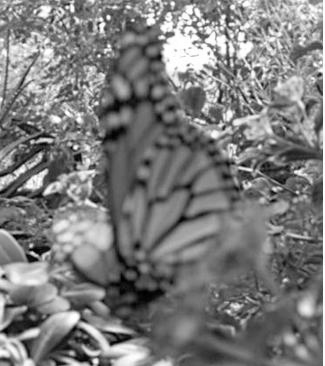

In [31]:
img = np.array(Image.open('LW_4_Fig_3.jpeg').convert('L'))
M = img.shape[1] // 2
img_left = img[:, :M]
img_right = img[:, M:]

img_left

In [32]:
orb = cv2.ORB_create(nfeatures=5000)
kp1, des1 = orb.detectAndCompute(img_left, None)
kp2, des2 = orb.detectAndCompute(img_right, None)

matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

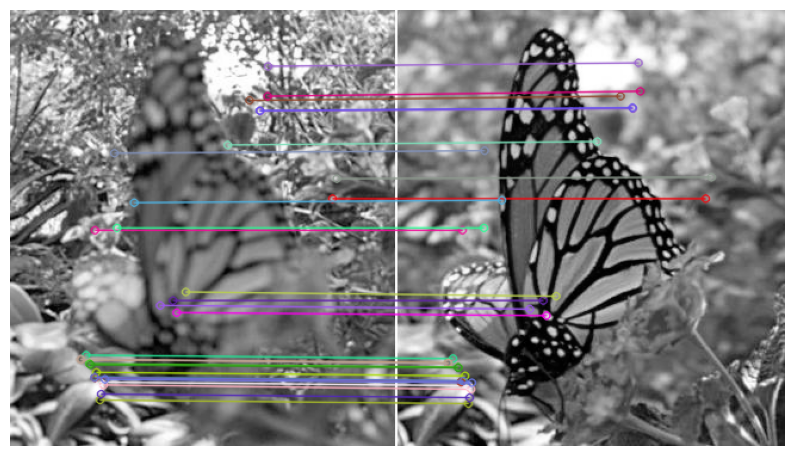

In [33]:
img_matches = cv2.drawMatches(img_left, kp1, img_right, kp2, matches[:30], None, flags=2)
plt.figure(figsize=(10, 6))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

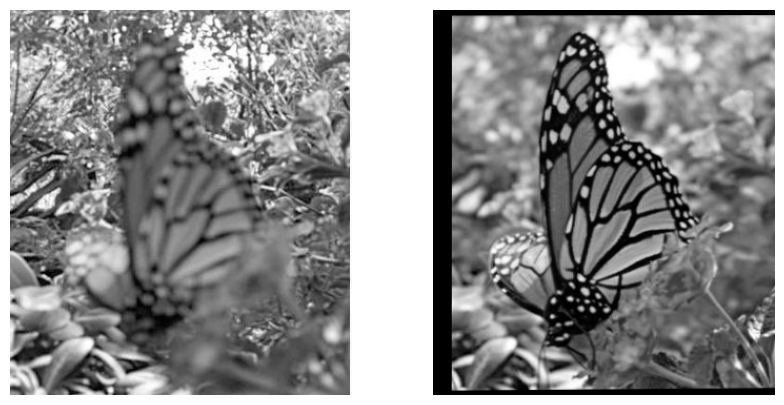

In [34]:
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches[:30]]).reshape(-1, 1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches[:30]]).reshape(-1, 1, 2)
H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC)

img_right_aligned = cv2.warpPerspective(img_right, H, (img_left.shape[1], img_left.shape[0]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_left, cmap='gray')
ax2.imshow(img_right_aligned, cmap='gray')
ax1.axis('off')
ax2.axis('off')
plt.show()

(np.float64(-0.5), np.float64(324.5), np.float64(365.5), np.float64(-0.5))

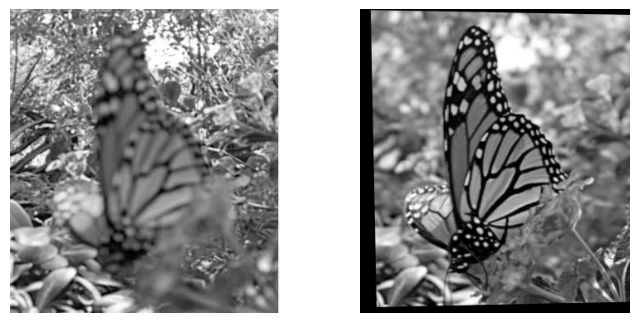

In [ ]:
''' Пострение гомографии. Ваш код.
    Результатом будет изображения img_1 и преобразованное img_2 -- изображение img_2_out.
'''

Вейвлет-разложения изображений будет осуществлять с помощью функции **wavedec2** библиотеки **PyWavelets**. Значение функции -- это список \[cAn, {cHn, cVn, cDn}, . . ., {cH1, cV1, cD1)}\]
![Image](wavedec2.JPG)

In [ ]:
wavelet = 'db8'
N = 3
coeffs_1 = pywt.wavedecn(img_1, wavelet = wavelet, level = N)
coeffs_2 = pywt.wavedecn(img_2_out, wavelet = wavelet, level = N)

In [ ]:
''' Алгоритм слияния ...
    Формируем новые матрицы коэффициентов ...
    Вейвлет-восстановление.
    Получаем новое изображение I.
    Оно примерно такое:
'''

(np.float64(-0.5), np.float64(325.5), np.float64(365.5), np.float64(-0.5))

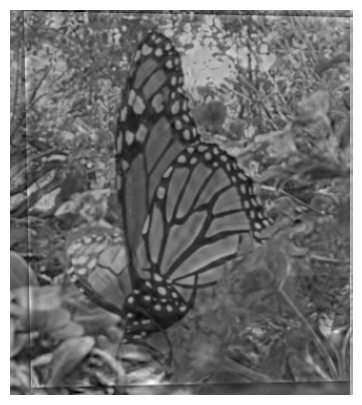

In [ ]:
fig = plt.figure(figsize = (5, 5))
plt.imshow(I, cmap = 'gray')
plt.axis('off')

In [35]:
X = img_left.astype(np.float32)
Y = img_right_aligned.astype(np.float32)
Y = cv2.resize(Y, (X.shape[1], X.shape[0]))

wavelet = 'db2'
coeffs_X = pywt.dwt2(X, wavelet)
coeffs_Y = pywt.dwt2(Y, wavelet)

cA_X, (cH_X, cV_X, cD_X) = coeffs_X
cA_Y, (cH_Y, cV_Y, cD_Y) = coeffs_Y

In [36]:
cA_Z = np.where(np.abs(cA_X) >= np.abs(cA_Y), cA_X, cA_Y)
cH_Z = np.where(np.abs(cH_X) >= np.abs(cH_Y), cH_X, cH_Y)
cV_Z = np.where(np.abs(cV_X) >= np.abs(cV_Y), cV_X, cV_Y)
cD_Z = np.where(np.abs(cD_X) >= np.abs(cD_Y), cD_X, cD_Y)

Z = pywt.idwt2((cA_Z, (cH_Z, cV_Z, cD_Z)), wavelet)

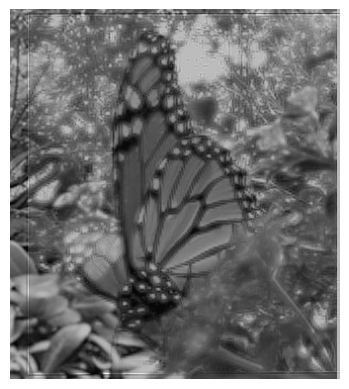

In [40]:
plt.subplot(1, 1, 1)
plt.imshow(Z, cmap='gray')
plt.axis('off')
plt.show()